# 11. Delta / Volatility feature 진단 — 변화율이 baseline 오차를 설명하나?

**가설**: state level (dsr_mean, dc10Tca)만으로는 partial cloud / cloud-pass event에서 정확히 예측이 어렵다. 변화율(`*_delta_1h`, `*_delta_2h`)과 변동성(`*_volatility_3h`)이 baseline의 큰 오차를 설명할 가능성.

**Step 4(TCN-trans)와의 차이**:
- Step 4: 같은 feature를 12h centered window 안에 넣어 TCN이 학습 → 평균 NMAE +0.19%p 악화, top event만 개선
- 본 노트북: 모델 추가 *전에* feature 자체가 baseline error와 상관 있는지 진단

**Leakage 금지**: cf_delta, cf_volatility 같은 target-leaking feature 절대 금지.

**진단 단계**:
1. weather-only delta/volatility feature 생성
2. dc10Tca / dsr_mean 등 기존 feature와의 redundancy 체크
3. partial cloud(bin 3~7) vs clear의 feature 분포 차이
4. **|baseline error|와 feature의 상관** (overall / partial / top event)
5. per-site (특히 광양항) 차이 확인
6. 결론: feature 추가가 정당화되는가?


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
import matplotlib as mpl, matplotlib.font_manager as fm
for f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic']:
    if any(f.lower() in n.name.lower() for n in fm.fontManager.ttflist):
        mpl.rcParams['font.family'] = f; break
mpl.rcParams['axes.unicode_minus'] = False

ROOT = Path('../..').resolve()
df = pd.read_parquet(ROOT / 'data/processed/training_set.parquet')
df = df[df.dsr_mean.notna() & df.cf.notna()].copy()
df = df.sort_values(['site','datetime_kst']).reset_index(drop=True)
df['rain'] = df['rn'].fillna(0)

# baseline 5-seed ensemble 예측 join (test set 평가용 errors)
ens = pd.read_parquet(ROOT / 'pv/experiments/resmlp_adaln_v2_ensemble/ensemble_test.parquet')
ens['datetime_kst'] = pd.to_datetime(ens['datetime_kst'])
print('전체 행:', len(df), '| ensemble test:', len(ens))


전체 행: 122974 | ensemble test: 32443


## 1. weather-only delta / volatility feature 생성

per-site, time-sorted로 계산.
- `dsr_delta_1h` = dsr_mean(t) - dsr_mean(t-1)
- `dsr_delta_2h` = dsr_mean(t) - dsr_mean(t-2)
- `cloud_delta_1h` = dc10Tca(t) - dc10Tca(t-1)
- `cloud_delta_2h` = dc10Tca(t) - dc10Tca(t-2)
- `dsr_volatility_3h` = rolling std (±3h centered, total 7h)
- `dsr_range_3h` = rolling max-min (±3h centered)
- `cloud_volatility_3h` = rolling std of dc10Tca (±3h)

NaN은 0으로 (시작/끝 부분).


In [2]:
def add_delta_vol(d, vol_win=3):
    d = d.sort_values(['site','datetime_kst']).reset_index(drop=True)
    g = d.groupby('site', group_keys=False)
    d['dsr_delta_1h']      = g['dsr_mean'].diff(1).fillna(0)
    d['dsr_delta_2h']      = g['dsr_mean'].diff(2).fillna(0)
    d['cloud_delta_1h']    = g['dc10Tca'].diff(1).fillna(0)
    d['cloud_delta_2h']    = g['dc10Tca'].diff(2).fillna(0)
    d['dsr_volatility_3h'] = g['dsr_mean'].transform(
        lambda s: s.rolling(2*vol_win+1, center=True, min_periods=1).std()).fillna(0)
    d['dsr_range_3h']      = g['dsr_mean'].transform(
        lambda s: s.rolling(2*vol_win+1, center=True, min_periods=1).apply(lambda x: x.max()-x.min(), raw=True)).fillna(0)
    d['cloud_volatility_3h']= g['dc10Tca'].transform(
        lambda s: s.rolling(2*vol_win+1, center=True, min_periods=1).std()).fillna(0)
    return d

df = add_delta_vol(df)
print('생성된 feature:')
new_feats = ['dsr_delta_1h','dsr_delta_2h','cloud_delta_1h','cloud_delta_2h',
             'dsr_volatility_3h','dsr_range_3h','cloud_volatility_3h']
print(df[new_feats].describe().round(3).T.to_string())


생성된 feature:
                        count     mean      std      min      25%      50%      75%      max
dsr_delta_1h         122974.0   -0.003  113.670 -755.983  -81.367   -0.633   82.246  767.183
dsr_delta_2h         122974.0   -0.008  194.996 -791.000 -148.046    0.502  145.060  760.817
cloud_delta_1h       122974.0    0.000    2.117  -10.000    0.000    0.000    1.000   10.000
cloud_delta_2h       122974.0   -0.000    2.764  -10.000   -1.000    0.000    1.000   10.000
dsr_volatility_3h    122974.0  152.224   67.415    6.474  102.879  142.435  198.842  402.893
dsr_range_3h         122974.0  399.054  168.790   17.987  276.100  376.596  522.167  963.883
cloud_volatility_3h  122974.0    1.688    1.275    0.000    0.690    1.496    2.628    5.345


→ **모델 함의**: |delta| 대표값 (예: dsr_delta_1h 표준편차)이 작으면 변화 자체가 약해 모델 입력으로 가치 적음. 표준편차가 dsr_mean 표준편차의 30%+면 의미있는 정보.


## 2. Redundancy — 기존 feature와 상관

새 feature들이 dc10Tca, dsr_mean과 얼마나 redundant한지. 너무 corr이 크면 feature 추가는 *동일 정보 재투입*이라 효과 없음.


In [3]:
focus = ['dsr_mean','dc10Tca','zenith_center','rain'] + new_feats
day = df[(df.zenith_center<60)].copy()  # daytime only
corr = day[focus].corr().round(3)
print('=== Pearson correlation (daytime, zenith<60) ===')
print(corr.to_string())
print()

# 가장 corr 높은 짝
print('\n=== 새 feature 별 기존 feature와 max |corr| ===')
old = ['dsr_mean','dc10Tca','zenith_center','rain']
for f in new_feats:
    cc = corr.loc[f, old].abs()
    top = cc.sort_values(ascending=False).head(2)
    print(f'  {f:<22} {top.index[0]}: {cc[top.index[0]]:+.3f}   {top.index[1]}: {cc[top.index[1]]:+.3f}')


=== Pearson correlation (daytime, zenith<60) ===
                     dsr_mean  dc10Tca  zenith_center   rain  dsr_delta_1h  dsr_delta_2h  cloud_delta_1h  cloud_delta_2h  dsr_volatility_3h  dsr_range_3h  cloud_volatility_3h
dsr_mean                1.000   -0.599         -0.420 -0.236         0.174         0.259          -0.008          -0.051              0.373         0.393                0.200
dc10Tca                -0.599    1.000         -0.132  0.164        -0.128        -0.197           0.211           0.272             -0.320        -0.302               -0.103
zenith_center          -0.420   -0.132          1.000 -0.044        -0.005        -0.034          -0.015          -0.023              0.150         0.113                0.133
rain                   -0.236    0.164         -0.044  1.000        -0.036        -0.064           0.002           0.006             -0.150        -0.154               -0.115
dsr_delta_1h            0.174   -0.128         -0.005 -0.036         1.000  

→ **모델 함의**: 새 feature가 기존 feature와 |corr|>0.7이면 *unique 정보 거의 없음*. <0.5면 새 신호 가능성 높음. 0.5~0.7은 modulation 효과만 있을 수 있음.


## 3. Partial cloud (bin 3~7) vs clear vs overcast — feature 분포 차이

각 regime에서 새 feature의 평균/표준편차가 어떻게 다른지. partial cloud에서 변동성이 크다는 것은 *자명*하지만, 그 차이의 *크기*가 진단 의미.


In [4]:
day = df[(df.zenith_center<60)].copy()
day['regime'] = np.where(day.dc10Tca<=2, 'CLEAR (dc≤2)',
                  np.where(day.dc10Tca>=8, 'OVERCAST (dc≥8)', 'PARTIAL (dc 3-7)'))
print(f"{'feature':<22} {'CLEAR mean':>12} {'PARTIAL mean':>14} {'OVERCAST mean':>15} {'PART/CLEAR':>11}")
for f in new_feats:
    g = day.groupby('regime')[f].agg(['mean','std'])
    cm = g.loc['CLEAR (dc≤2)','std']
    pm = g.loc['PARTIAL (dc 3-7)','std']
    om = g.loc['OVERCAST (dc≥8)','std']
    print(f'  {f:<22} std={cm:>9.3f}   std={pm:>11.3f}   std={om:>12.3f}   ratio={pm/cm:>8.2f}x')


feature                  CLEAR mean   PARTIAL mean   OVERCAST mean  PART/CLEAR
  dsr_delta_1h           std=  101.764   std=    118.068   std=     114.151   ratio=    1.16x
  dsr_delta_2h           std=  181.492   std=    193.461   std=     166.786   ratio=    1.07x
  cloud_delta_1h         std=    1.586   std=      2.163   std=       1.133   ratio=    1.36x
  cloud_delta_2h         std=    2.119   std=      2.689   std=       1.606   ratio=    1.27x
  dsr_volatility_3h      std=   70.135   std=     67.198   std=      70.312   ratio=    0.96x
  dsr_range_3h           std=  170.791   std=    163.684   std=     178.362   ratio=    0.96x
  cloud_volatility_3h    std=    1.253   std=      0.860   std=       1.000   ratio=    0.69x


→ **모델 함의**: ratio (partial/clear) 가 크면 (예: 3x+) partial cloud에서 정보가 풍부, regime detector로 사용 가능. 1x 근처면 변별력 없음.


## 4. ★ 핵심: |baseline error|와 feature의 상관

테스트 셋에서 baseline ensemble의 error = |cf - mu_mean|. 각 feature와 |error|의 Pearson corr 측정.

**판독 기준**:
- |corr| > 0.20: 의미있는 신호 (feature 추가 시 개선 기대)
- 0.10~0.20: 약한 신호 (다른 feature와 결합 시만 도움)
- < 0.10: feature 추가해도 거의 효과 없음

3 segment로 나누어:
- **overall** (test 전체)
- **partial cloud (dc10Tca 3~7)**
- **top cloud-pass events** (2025-03-23, 04-26, 05-04 정오~15시)


In [5]:
# Test set에 새 feature 붙이기 (df에서 join)
key = ['datetime_kst','site']
# df는 이미 새 feature 가지고 있음
test_full = ens.merge(df[key + ['dsr_mean','dc10Tca','zenith_center','rain'] + new_feats],
                       on=key, how='left')
test_full['err'] = (test_full.cf - test_full.mu_mean).abs()
print(f'merged rows: {len(test_full)} (NaN err? {test_full.err.isna().sum()})')

def corr_segment(d, name):
    print(f'\n=== |error| vs feature ({name}, n={len(d)}) ===')
    print(f'  {"feature":<22} {"corr":>7}')
    rows = []
    for f in new_feats + ['dc10Tca','dsr_mean','rain']:
        c = d[[f,'err']].corr().iloc[0,1]
        rows.append((f, c))
    rows.sort(key=lambda x: -abs(x[1]))
    for f, c in rows:
        marker = '★' if abs(c)>=0.20 else ('·' if abs(c)>=0.10 else '')
        print(f'  {f:<22} {c:>+6.3f}  {marker}')
    return rows

# overall
_ = corr_segment(test_full, 'overall test')
# partial cloud
pc = test_full[(test_full.dc10Tca>=3) & (test_full.dc10Tca<=7)]
_ = corr_segment(pc, 'partial cloud (dc 3~7)')
# top events
events = pd.to_datetime(['2025-03-23','2025-04-26','2025-05-04'])
ev_mask = test_full.datetime_kst.dt.normalize().isin(events) & \
           (test_full.datetime_kst.dt.hour.between(12,15))
_ = corr_segment(test_full[ev_mask], 'top cloud-pass events (12~15h)')


merged rows: 32443 (NaN err? 0)

=== |error| vs feature (overall test, n=32443) ===
  feature                   corr
  dsr_mean               +0.299  ★
  dsr_delta_2h           +0.124  ·
  dc10Tca                -0.069  
  dsr_delta_1h           +0.051  
  rain                   -0.049  
  dsr_volatility_3h      +0.022  
  dsr_range_3h           +0.017  
  cloud_delta_1h         -0.017  
  cloud_volatility_3h    -0.012  
  cloud_delta_2h         -0.010  

=== |error| vs feature (partial cloud (dc 3~7), n=8733) ===
  feature                   corr
  dsr_mean               +0.238  ★
  dsr_delta_2h           +0.104  ·
  cloud_volatility_3h    -0.084  
  dsr_range_3h           -0.063  
  dsr_volatility_3h      -0.062  
  cloud_delta_1h         -0.052  
  dsr_delta_1h           +0.043  
  cloud_delta_2h         -0.034  
  dc10Tca                -0.024  
  rain                   +0.002  

=== |error| vs feature (top cloud-pass events (12~15h), n=96) ===
  feature                   corr
  dsr

→ **판정**:
- overall에서 |corr|>0.2인 feature가 있으면 → 평균 NMAE 개선 기대 (feature 추가 정당화)
- partial cloud에서만 강하면 → regime-conditional 사용 가치 (전체엔 영향 적을 수 있음)
- top event에서만 강하면 → Step 4 결과와 일치 (event-only 효과)
- 모두에서 약하면 → feature 추가 폐기, Step 4가 실패한 본질적 이유 (feature 자체에 신호 부족)


## 5. Per-site break — 광양항세방 / 예천 vs GOOD

문제 사이트와 GOOD 사이트에서 |error| vs feature 상관이 다른가? 다르면 site × feature interaction이 의미 있음.


In [6]:
GOOD = ['경상대','고흥만수상','영흥','삼천포','구미']
PROBLEM = ['광양항세방','예천','창원']

print('=== |error| vs feature, site별 (overall test) ===')
print(f"  {'site':<10}", end='')
for f in new_feats:
    print(f" {f.replace('_volatility','_vol').replace('_delta','_d'):>14}", end='')
print()
for site in GOOD + PROBLEM:
    sub = test_full[test_full.site==site]
    if len(sub)<50: continue
    print(f'  {site:<10}', end='')
    for f in new_feats:
        c = sub[[f,'err']].corr().iloc[0,1]
        marker = '★' if abs(c)>=0.20 else (' ' if abs(c)>=0.10 else ' ')
        print(f' {c:>+12.3f}{marker}', end='')
    print()


=== |error| vs feature, site별 (overall test) ===
  site             dsr_d_1h       dsr_d_2h     cloud_d_1h     cloud_d_2h     dsr_vol_3h   dsr_range_3h   cloud_vol_3h
  경상대              -0.014        +0.041        -0.014        -0.000        -0.002        -0.007        -0.016 
  고흥만수상            +0.032        +0.085        +0.011        +0.036        -0.071        -0.070        -0.019 
  영흥               +0.025        +0.091        -0.044        -0.060        -0.080        -0.090        +0.037 
  삼천포              +0.105        +0.183        +0.012        +0.014        -0.049        -0.056        +0.021 
  구미               +0.129        +0.169        -0.092        -0.059        +0.050        +0.043        +0.075 
  광양항세방            +0.093        +0.188        -0.007        +0.005        +0.147        +0.146        -0.043 
  예천               +0.176        +0.252★       -0.048        -0.043        +0.105        +0.099        +0.023 
  창원               -0.089        +0.031        +0.007   

→ **모델 함의**: 광양항/예천에서만 강한 corr이 보이면 baseline 추가보다 *site × feature interaction*이 답. GOOD/PROBLEM 모두 비슷하면 baseline 단순 추가로 충분.


## 6. Top event 시각화 — 실제 cloud-pass 사건 안에서 모델이 어떻게 틀렸는지

2025-04-26 정오~15시 portfolio prediction vs actual + 새 feature 곡선. 구름 통과 이벤트 안에서 cloud_delta가 cf 변동을 따라가는지 시각적 확인.


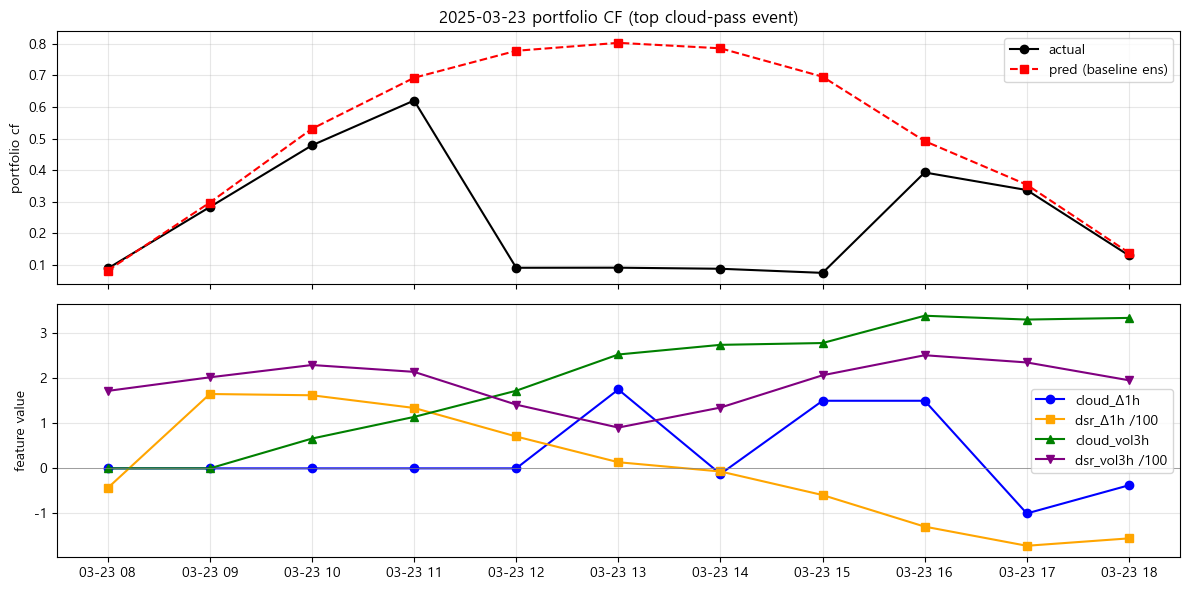

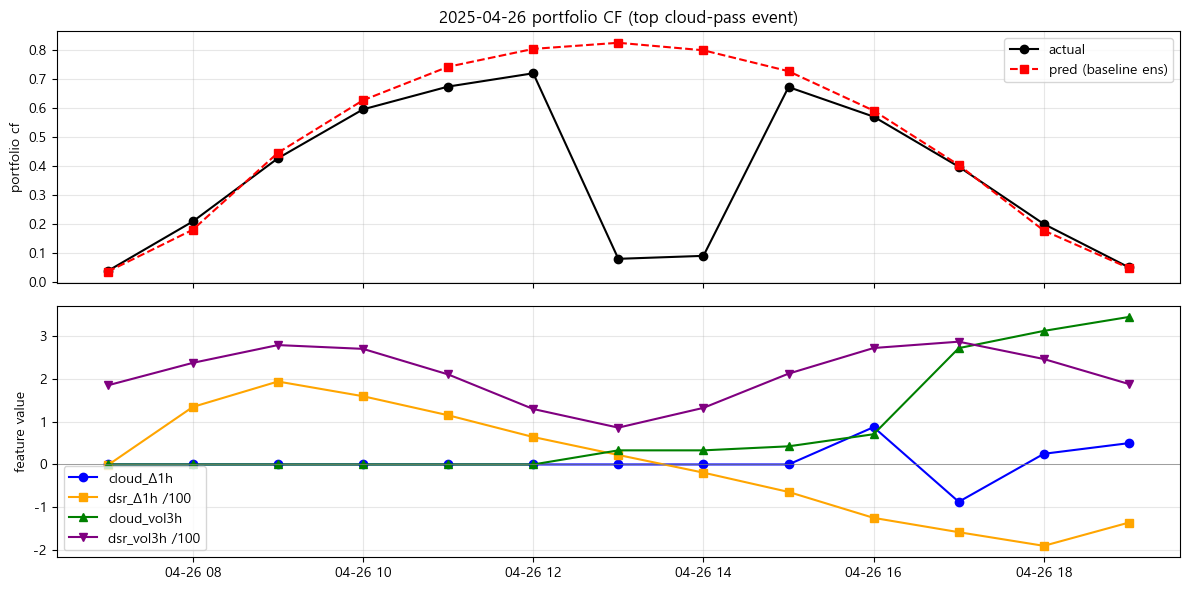

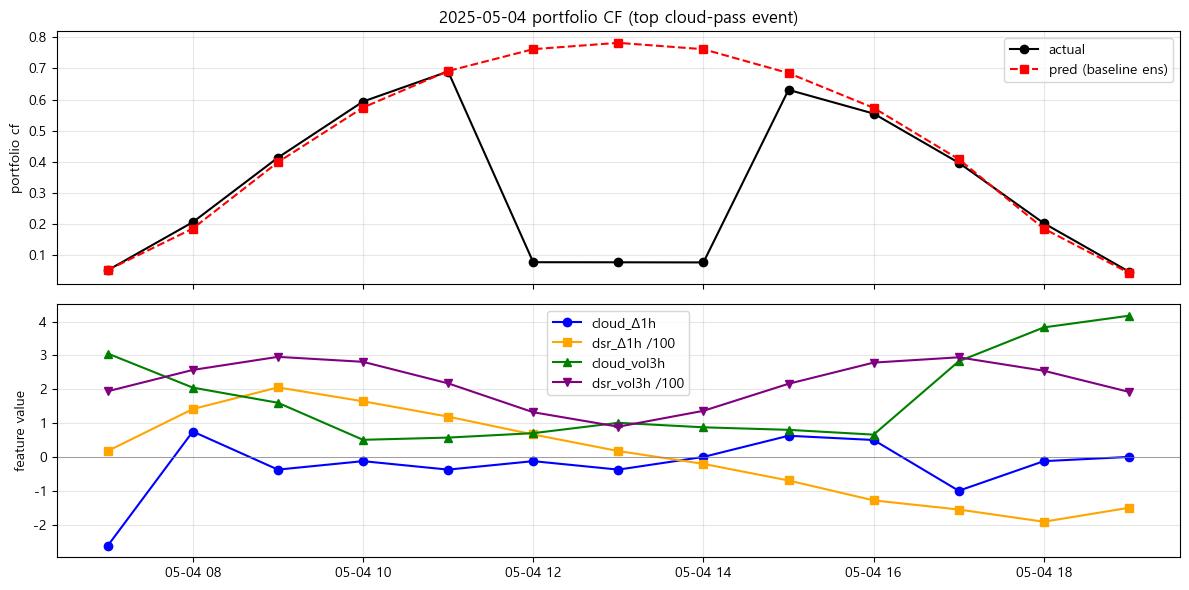

In [7]:
for ev_date in ['2025-03-23', '2025-04-26', '2025-05-04']:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    d = test_full[test_full.datetime_kst.dt.normalize() == pd.Timestamp(ev_date)]
    if len(d)==0: continue
    # portfolio aggregation
    p = d.assign(pred_kwh=d.mu_mean*d.site_capacity_kw,
                  actual_kwh=d.cf*d.site_capacity_kw)
    port = p.groupby('datetime_kst', as_index=False).agg(
        pred=('pred_kwh','sum'), actual=('actual_kwh','sum'),
        cap=('site_capacity_kw','sum'),
        cloud_d1=('cloud_delta_1h','mean'),
        dsr_d1=('dsr_delta_1h','mean'),
        cloud_v=('cloud_volatility_3h','mean'),
        dsr_v=('dsr_volatility_3h','mean'),
    )
    port['pred_cf'] = port.pred / port.cap
    port['actual_cf'] = port.actual / port.cap
    ax = axes[0]
    ax.plot(port.datetime_kst, port.actual_cf, 'o-', color='black', label='actual')
    ax.plot(port.datetime_kst, port.pred_cf, 's--', color='red', label='pred (baseline ens)')
    ax.set_ylabel('portfolio cf')
    ax.set_title(f'{ev_date} portfolio CF (top cloud-pass event)')
    ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1]
    ax.plot(port.datetime_kst, port.cloud_d1, 'o-', color='blue', label='cloud_Δ1h')
    ax.plot(port.datetime_kst, port.dsr_d1/100, 's-', color='orange', label='dsr_Δ1h /100')
    ax.plot(port.datetime_kst, port.cloud_v, '^-', color='green', label='cloud_vol3h')
    ax.plot(port.datetime_kst, port.dsr_v/100, 'v-', color='purple', label='dsr_vol3h /100')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylabel('feature value')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


→ **시각 판독**:
- pred가 actual을 *부드럽게* 따라가면서 큰 dip을 못 잡음 → cloud_delta가 큰 시점이 그 dip과 일치하면 feature 가치 있음
- pred와 actual의 misalignment 위치 = cloud_volatility 큰 시점이 일치하면 regime detector로 가치


## 7. 종합 판정

| 결과 | 결정 |
|---|---|
| overall |corr| > 0.2 | baseline cond에 4개 feature 추가, 단순 실험 |
| partial cloud only > 0.2 | regime gating (dc10Tca 기반) + delta cond 추가 |
| top event만 > 0.2 | event detector 분리 (작은 모델로 큰 ramp 탐지) |
| 모두 < 0.1 | feature 추가 폐기, Step 4의 실패 이유 = "신호 자체 부족" 확인 |
| problem site에서만 강함 | site × feature interaction (한 사이트씩) |

이 노트북 결과로 다음 단계 결정:
1. 위 표에서 어느 분기인지 명확히
2. 분기에 맞는 *최소 변경* 실험 1개만 (feature 4개 cond 추가, 다른 모든 설정 동일)
3. UNIFIED config (batch=64, lr=7e-4, MAE+0.2·NLL, max_ep=50, patience=8) 그대로
